In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from data import fetch_data
from strategies import ma_crossover_signal, momentum_signal
from backtest import backtest, annualised_return, annualised_volume, drawdown_series, max_drawdown
from backtest import sharpe_ratio, build_sharpe_grid, metrics_summary, metrics_summary_df

In [2]:
short_window = 20
long_window = 50
lookback = 126
tickers = ["AAPL", "MSFT", "JPM", "XOM", "PFE"]

data = fetch_data(tickers)
df = data["AAPL"]

df['ma_short'] = df['Close'].rolling(short_window).mean()
df['ma_long'] = df['Close'].rolling(long_window).mean()
df['signal'] = (df['ma_short'] > df['ma_long']).astype(int)

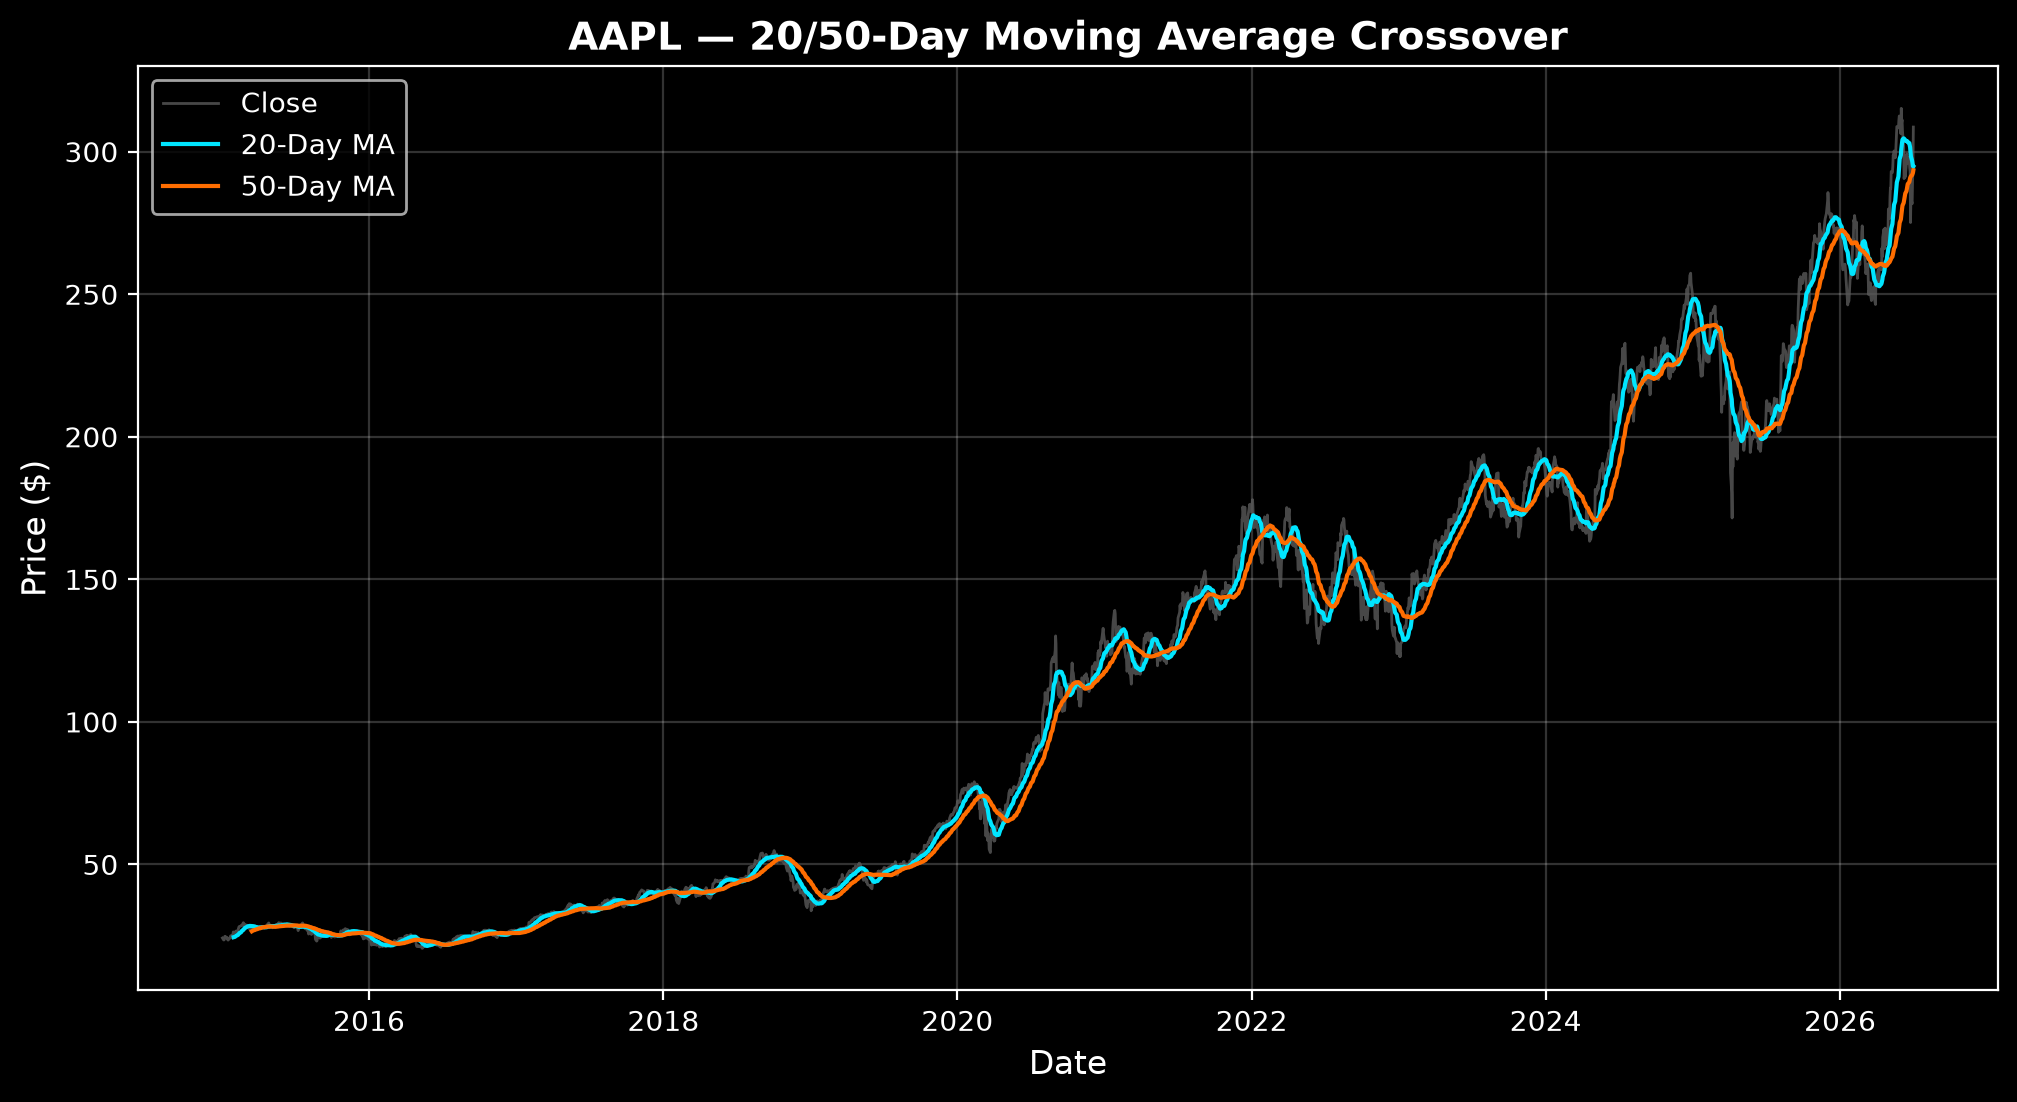

In [3]:
plt.style.use('dark_background')

plt.figure(figsize = (12, 6), dpi = 200)
plt.plot(df['Close'], label = 'Close', color = '#5A5A5A', linewidth = 1, alpha = 0.8)
plt.plot(df['ma_short'], label = f'{short_window}-Day MA', color = "#00E5FF", linewidth = 1.5)
plt.plot(df['ma_long'], label = f'{long_window}-Day MA', color = '#FF6D00', linewidth = 1.5)

plt.grid(alpha = 0.2)
plt.title('AAPL — 20/50-Day Moving Average Crossover', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Price ($)', fontsize = 12)
plt.legend()

plt.savefig('../plots/aapl_ma_crossover.png', dpi = 200)
plt.show()

In [4]:
df['momentum'] = df['Close'].pct_change(lookback) * 100
df['signal'] = (df['momentum'] > 0).astype(int)

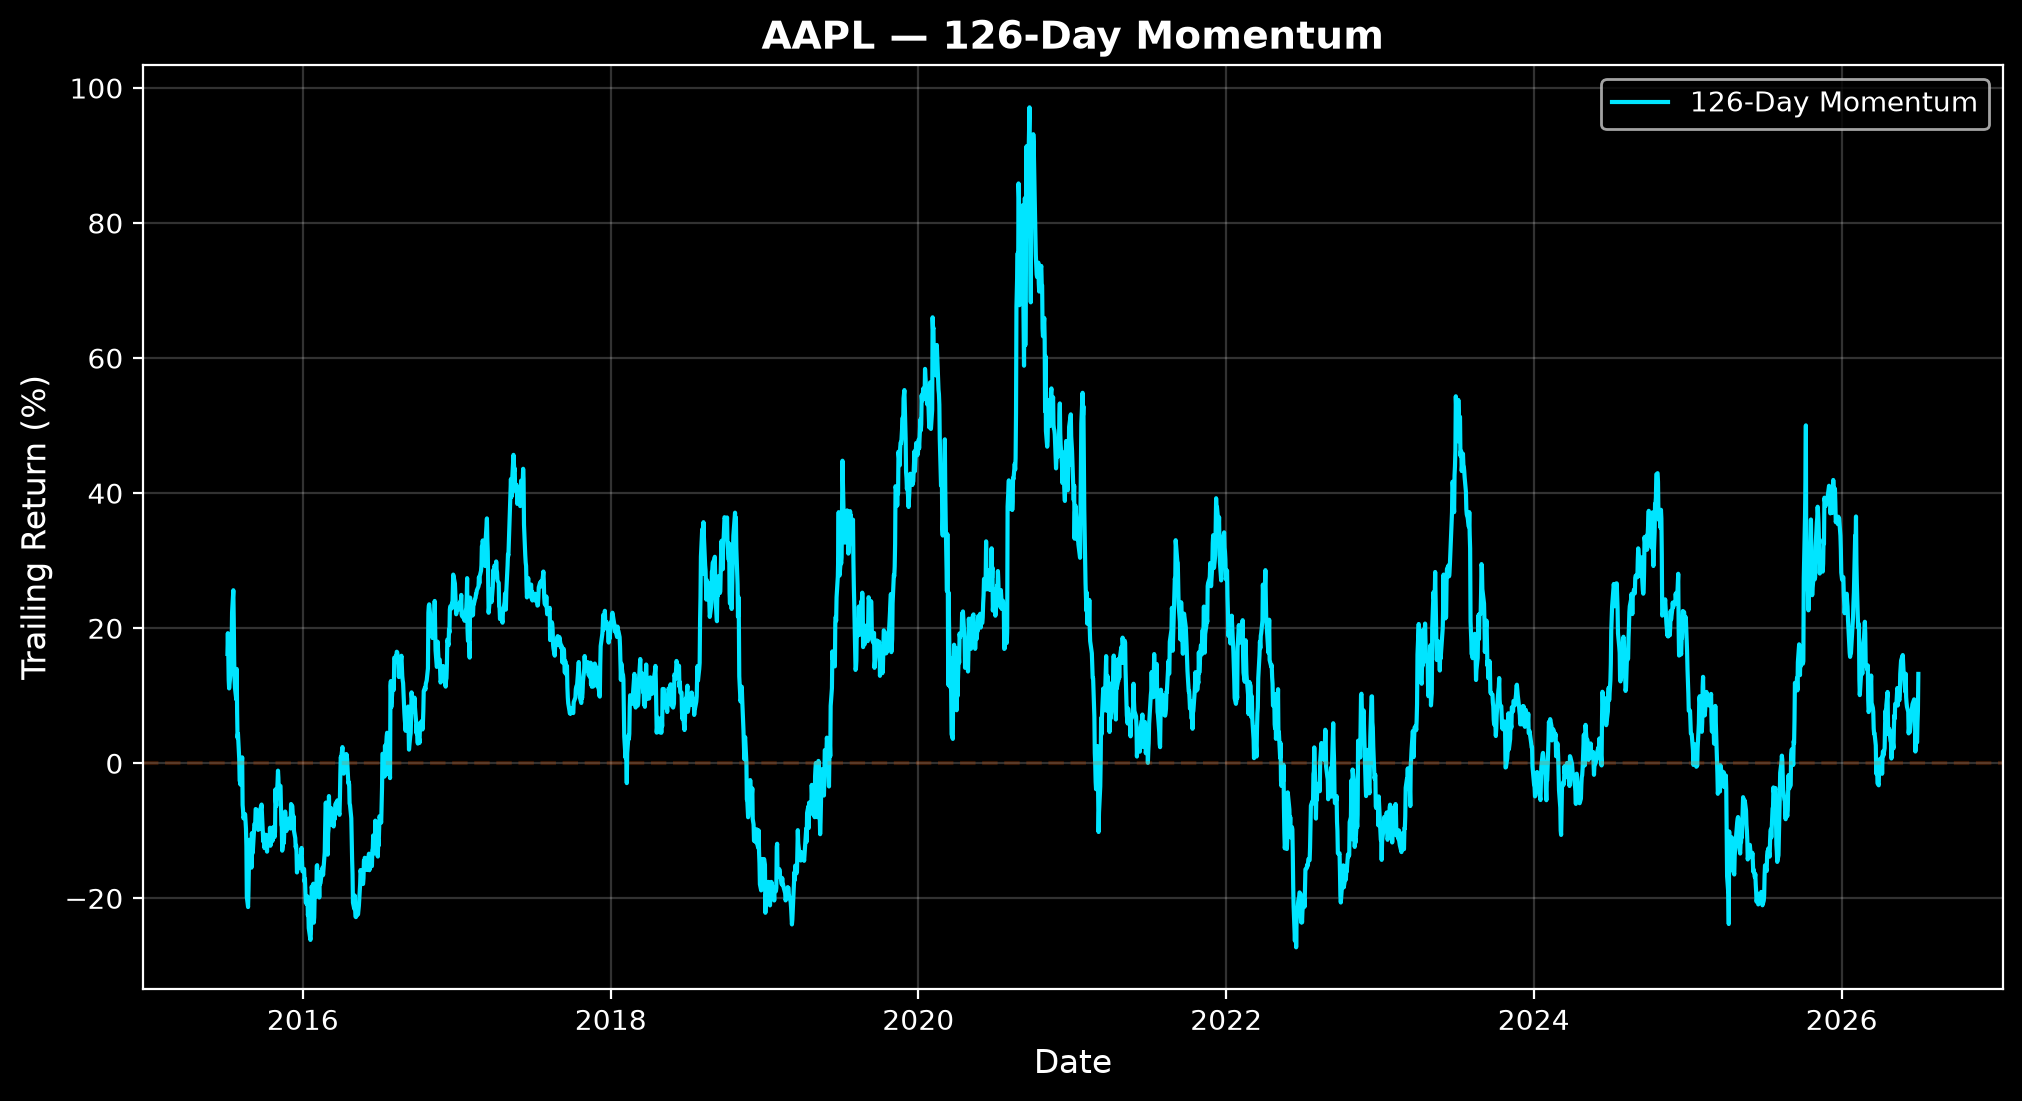

In [5]:
plt.figure(figsize = (12, 6), dpi = 200)
plt.plot(df['momentum'], label = f'{lookback}-Day Momentum', color = '#00E5FF', linewidth = 1.5)

plt.axhline(0, color = '#FF5E00', linestyle = '--', alpha = 0.2)
plt.grid(alpha = 0.2)
plt.title(f'AAPL — {lookback}-Day Momentum', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Trailing Return (%)', fontsize = 12)
plt.legend()

plt.savefig('../plots/aapl_momentum.png', dpi = 200)
plt.show()

In [6]:
cost_per_trade = 0.001

signals = ma_crossover_signal(df)
signals['signal_shifted'] = signals['signal'].shift(1)

df['returns'] = df['Close'].pct_change()
strategy_returns = signals['signal_shifted'] * df['returns']
trades = signals['signal_shifted'].diff().abs()
strategy_returns_net = strategy_returns - (trades * cost_per_trade)
returns, equity_curve = backtest(data["AAPL"], ma_crossover_signal(data["AAPL"]))

buy_and_hold = (1 + df['Close'].pct_change().fillna(0)).cumprod()

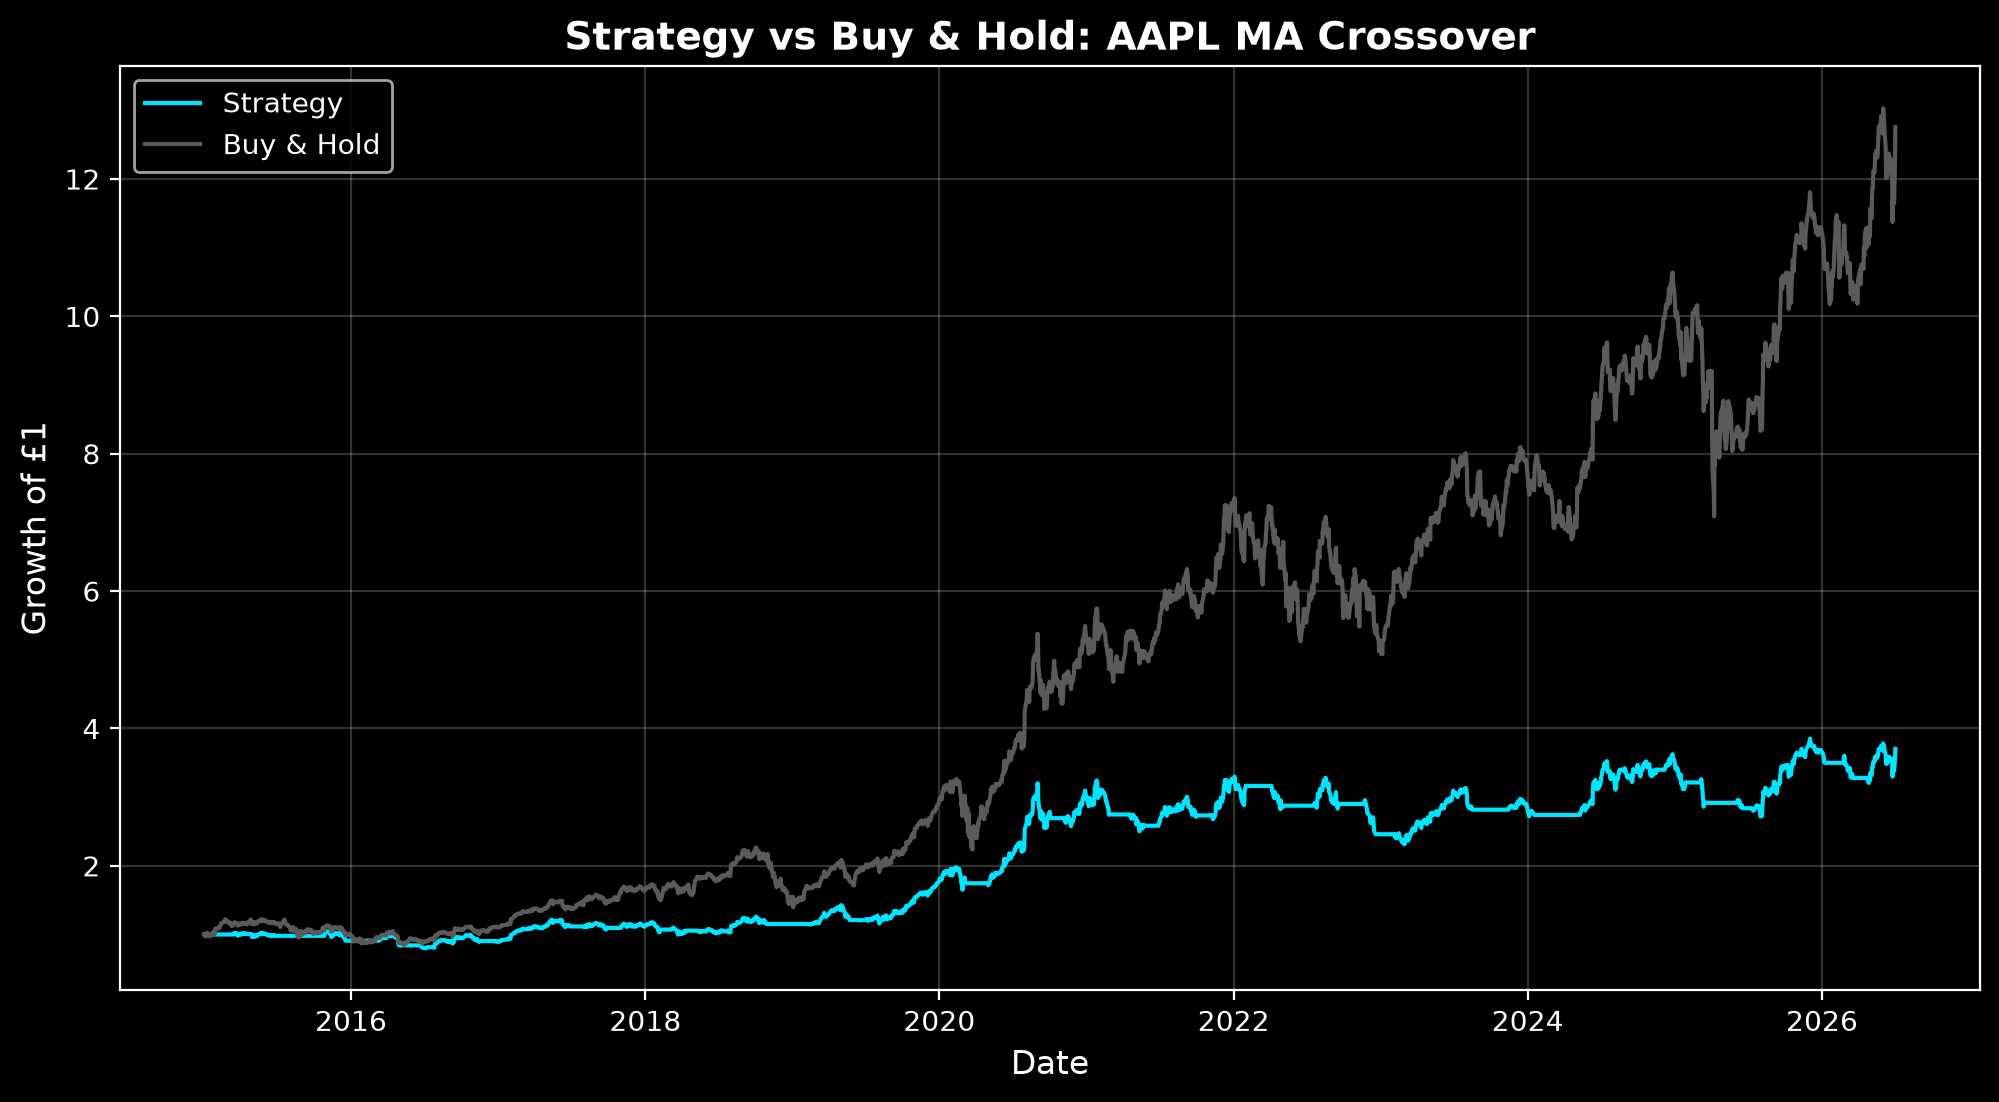

In [7]:
plt.figure(figsize = (12, 6), dpi = 200)
plt.plot(equity_curve, label = 'Strategy', color = '#00E5FF', linewidth = 1.5)
plt.plot(buy_and_hold, label = 'Buy & Hold', color = '#5A5A5A', linewidth = 1.5)

plt.grid(alpha = 0.2)
plt.title('Strategy vs Buy & Hold: AAPL MA Crossover', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Growth of £1', fontsize = 12)
plt.legend()

plt.savefig('../plots/aapl_ma_crossover_vs_buy_and_hold.png', dpi = 200)
plt.show()

In [8]:
short_windows = [10, 15, 20, 25, 30]
long_windows = [40, 50, 60, 70, 80]

for ticker, df in data.items():
    signals = ma_crossover_signal(df)
    returns, equity = backtest(df, signals)
    summary = metrics_summary_df(returns, equity, ticker = ticker)

grids = {ticker: build_sharpe_grid(ticker, short_windows, long_windows, data) for ticker in tickers} 
all_values = pd.concat([g.stack() for g in grids.values()])
vmin, vmax = all_values.min(), all_values.max()   

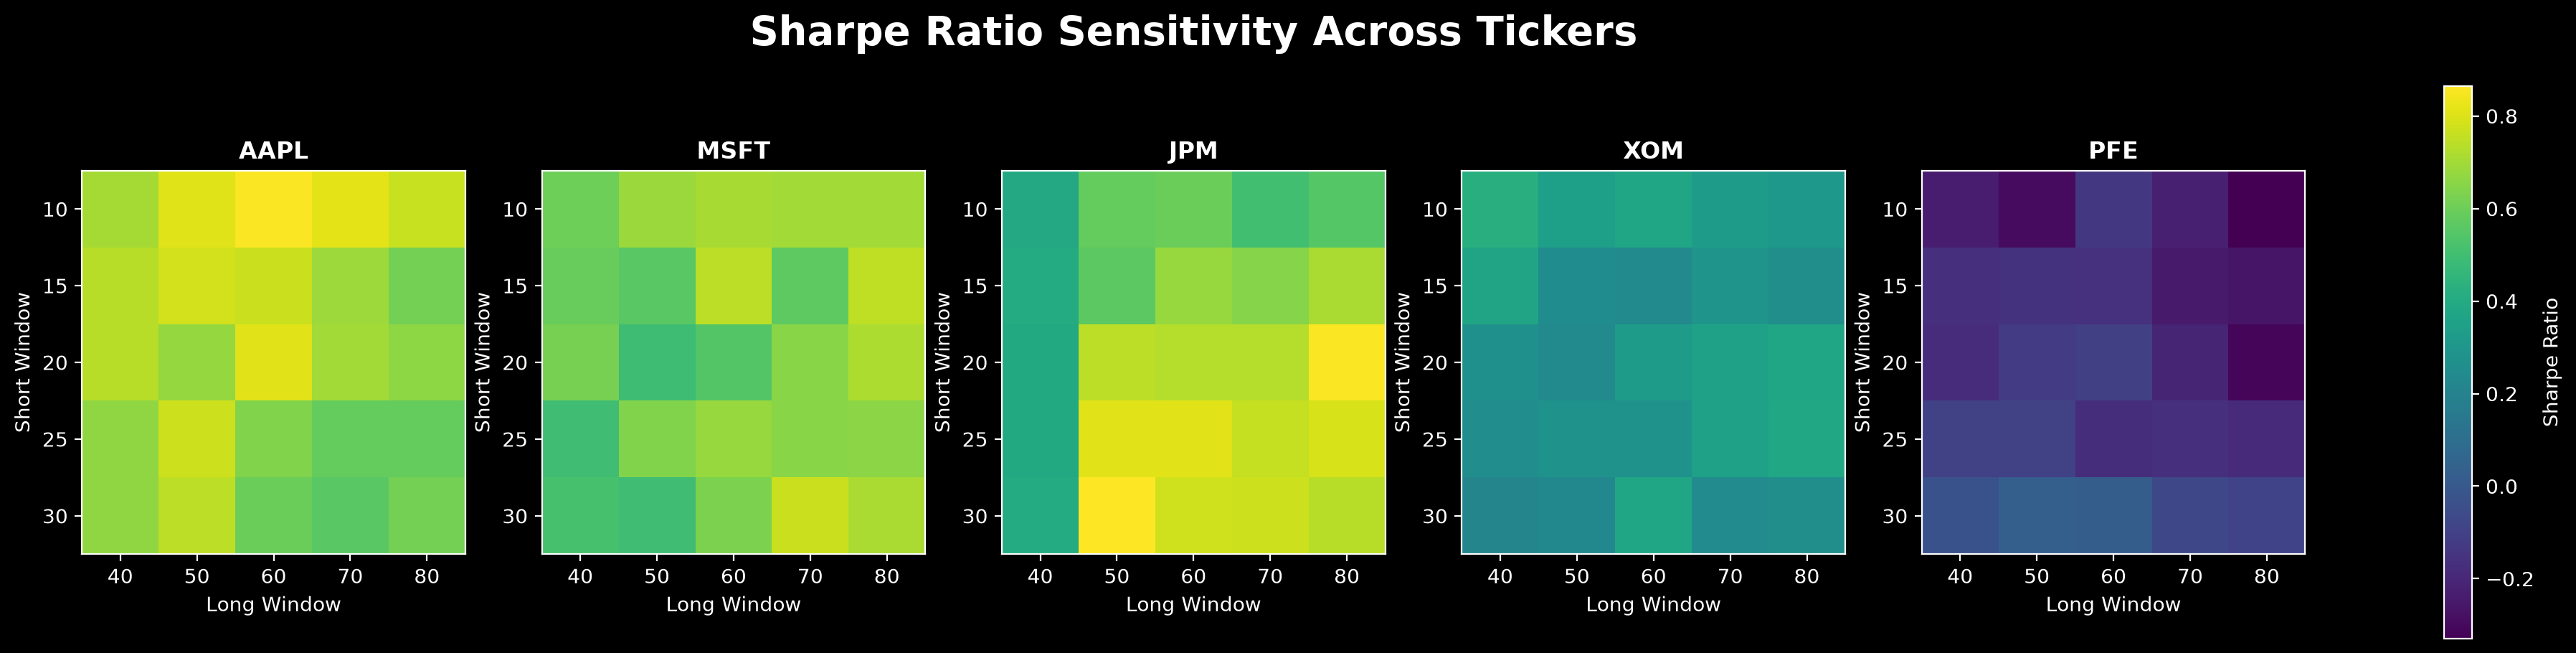

In [9]:
fig, axes = plt.subplots(1, len(tickers), figsize = (5 * len(tickers), 5), dpi = 200)

for ax, ticker in zip(axes, tickers):
    grid = grids[ticker]
    im = ax.imshow(grid.values, vmin = vmin, vmax = vmax)

    ax.set_xticks(range(len(long_windows)))
    ax.set_xticklabels(long_windows)
    ax.set_yticks(range(len(short_windows)))
    ax.set_yticklabels(short_windows)
    ax.set_xlabel('Long Window')
    ax.set_ylabel('Short Window')
    
    ax.set_title(ticker, fontweight = 'bold')

fig.colorbar(im, ax = axes, label = 'Sharpe Ratio')
plt.suptitle('Sharpe Ratio Sensitivity Across Tickers', fontsize = 20, fontweight = 'bold', x = 0.435)

plt.savefig('../plots/sharpe_ratio_sensitivity.png', dpi = 200)
plt.show()

In [10]:
dd_strategy = drawdown_series(equity)
dd_buyhold = drawdown_series(buy_and_hold)

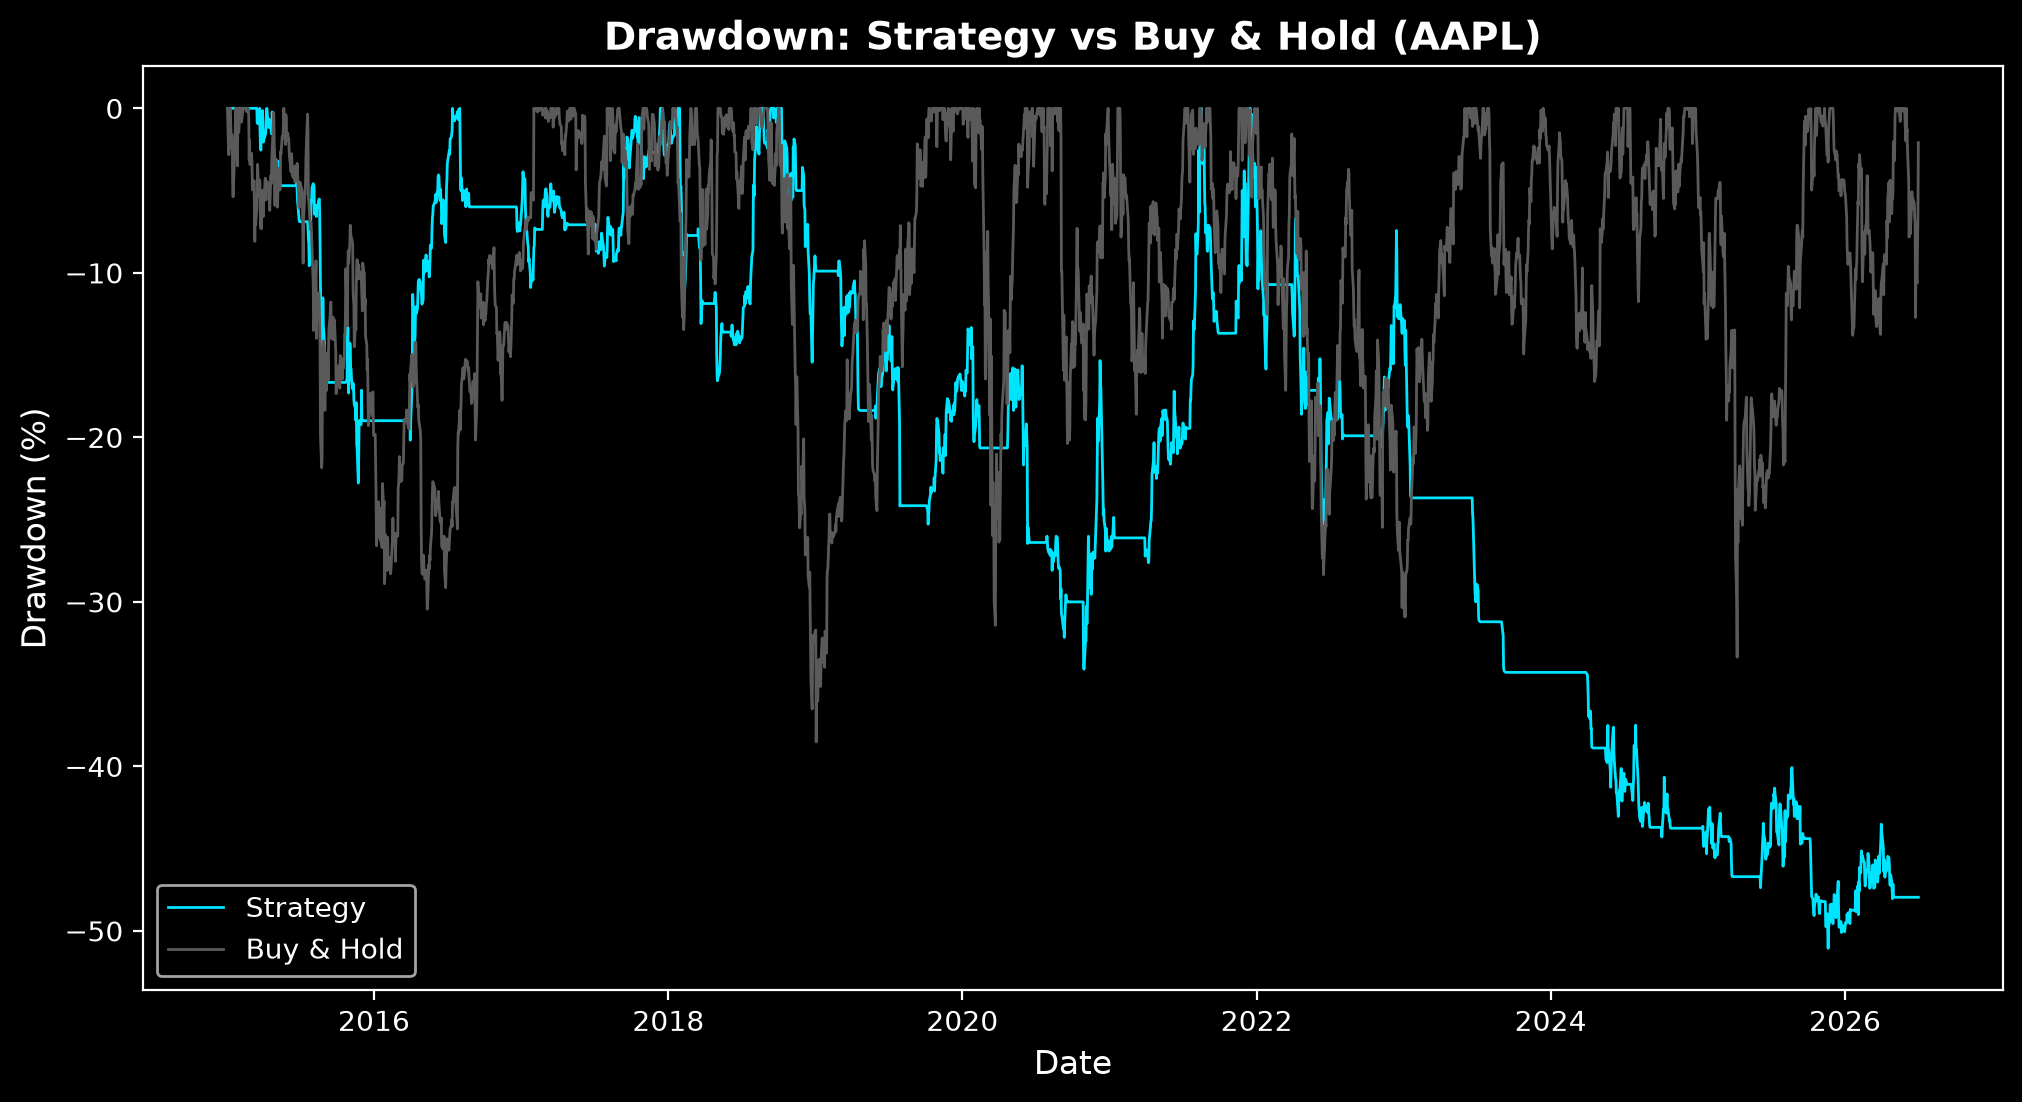

In [11]:
plt.figure(figsize = (12, 6), dpi = 200)
plt.plot(dd_strategy * 100, label = 'Strategy', color = '#00E5FF', linewidth = 1)
plt.plot(dd_buyhold * 100, label = 'Buy & Hold', color = '#5A5A5A', linewidth = 1)

plt.title('Drawdown: Strategy vs Buy & Hold (AAPL)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Drawdown (%)', fontsize = 12)
plt.legend()

plt.savefig('../plots/aapl_drawdown_strategy_vs_buy_and_hold.png', dpi = 200)
plt.show()

In [12]:
all_summaries = {}

for ticker, df in data.items():
    signals = ma_crossover_signal(df)
    returns, equity = backtest(df, signals)

    buy_and_hold = (1 + df['Close'].pct_change().fillna(0)).cumprod()
    ann_ret_bh = annualised_return(buy_and_hold)
    
    summary = metrics_summary(returns, equity)
    summary['buy_and_hold'] = ann_ret_bh
    all_summaries[ticker] = summary

results_df = pd.DataFrame(all_summaries).T

In [13]:
results_df_display = results_df.copy()

results_df_display['annualised_return'] = results_df_display['annualised_return'].apply(lambda x: f"{x:.2%}")
results_df_display['annualised_volume'] = results_df_display['annualised_volume'].apply(lambda x: f"{x:.2%}")
results_df_display['max_drawdown'] = results_df_display['max_drawdown'].apply(lambda x: f"{x:.2%}")
results_df_display['buy_and_hold'] = results_df_display['buy_and_hold'].apply(lambda x: f"{x:.2%}")
results_df_display['sharpe'] = results_df_display['sharpe'].round(3)
results_df_display['t_stat'] = results_df_display['t_stat'].round(3)
results_df_display['p_value'] = results_df_display['p_value'].round(3)

results_df_display = results_df_display.rename(columns = {
    'annualised_return': 'Annualised Return',
    'annualised_volume': 'Annualised Volume',
    'sharpe': 'Sharpe Ratio',
    'max_drawdown': 'Max Drawdown',
    't_stat': 'T-Statistic',
    'p_value': 'P-Value',
    'buy_and_hold': 'Buy & Hold Return'
})

n_cols = len(results_df_display.columns)
markdown_table = results_df_display.to_markdown(colalign = ["center"] * (n_cols + 1))

print(markdown_table)

with open('../plots/results_table.md', 'w') as f:
    f.write(markdown_table)

|      |  Annualised Return  |  Annualised Volume  |  Sharpe Ratio  |  Max Drawdown  |  T-Statistic  |  P-Value  |  Buy & Hold Return  |
|:----:|:-------------------:|:-------------------:|:--------------:|:--------------:|:-------------:|:---------:|:-------------------:|
| AAPL |       12.08%        |       19.70%        |     0.678      |    -29.80%     |     2.296     |   0.022   |       24.85%        |
| MSFT |        8.17%        |       19.85%        |     0.495      |    -44.07%     |     1.675     |   0.094   |       22.06%        |
| JPM  |       12.50%        |       18.03%        |     0.743      |    -24.12%     |     2.517     |   0.012   |       18.82%        |
| XOM  |        2.82%        |       19.14%        |     0.241      |    -36.88%     |     0.816     |   0.414   |        7.93%        |
| PFE  |       -3.18%        |       16.06%        |     -0.121     |    -51.06%     |    -0.409     |   0.683   |        2.62%        |
